In [2]:
import pandas as pd
import numpy as np

INPUT_CSV = "fire_weather.csv"
ENCODING = "cp949"

# 1) 유틸작업
def hhmm_to_min(series: pd.Series) -> pd.Series:
    """HH:MM 문자열 정리 (초 없음)"""
    s = series.astype(str).str.strip()
    s = s.replace({"nan":"", "NaN":"", "None" : "", "<NA>": ""})

    # HH:MM이 아니면 빈값 처리 -> NaT로 감
    s = s.where(s.str.match(r"^\d{1,2}:\d{2}$"), np.nan)

    hh = pd.to_numeric(s.str.split(":").str[0], errors="coerce")
    mm = pd.to_numeric(s.str.split(":").str[1], errors="coerce")

    out = hh*60 + mm
    return out

# 2) 데이터 로드
df = pd.read_csv(INPUT_CSV, encoding=ENCODING)

print("✅ loaded: ", df.shape)
print("📋 columns sample: ", df.columns.tolist()[:30])
df.head(3)


✅ loaded:  (5520, 67)
📋 columns sample:  ['인명피해(명)소계', '사망', '부상', '소방서', '119안전센터', '119지역대', '화재발생(년)', '화재발생(월)', '화재발생(요일)', '화재발생(시각)', '접수(년)', '접수(월)', '접수(요일)', '접수(시각)', '출동(년)', '출동(월)', '출동(요일)', '출동(시각)', '도착(년)', '도착(월)', '도착(요일)', '도착(시각)', '출동소요시간', '시도', '시군구', '읍면동', '지번동', '지번리', '세부주소', '도로명주소']


,인명피해(명)소계,사망,부상,소방서,119안전센터,119지역대,화재발생(년),화재발생(월),화재발생(요일),화재발생(시각),...,출동소요총초,출동소요등급,비눈여부,기온범주,풍속등급,습도등급,주야구분,계절,이슬점차(°C),체감온도(°C)
0,0,0,0,강서소방서,죽전119안전센터,NaN,2021,1,금요일,19:17,...,261,5분이내,0,저온,약풍,습함,야간,겨울,4.6,0.100000
1,1,0,1,중부소방서,성명119안전센터,대명119지역대,2021,1,토요일,9:30,...,241,5분이내,0,영하,약풍,습함,주간,겨울,4.9,-5.381810
2,0,0,0,동부소방서,신천119안전센터,NaN,2021,1,토요일,11:02,...,269,5분이내,0,저온,약풍,보통,주간,겨울,11.1,-3.986268


In [3]:
# 3) 분(min) 컬럼 생성
df["접수_min"] = hhmm_to_min(df["접수(시각)"])
df["출동_min"] = hhmm_to_min(df["출동(시각)"])
df["도착_min"] = hhmm_to_min(df["도착(시각)"])

# 4) 시간 지표 생성 (분 단위)
df["출동지연시간"] = (df["출동_min"] - df["접수_min"])
df["총소요시간"] = (df["도착_min"] - df["접수_min"])
df["이동시간"] = (df["도착_min"] - df["출동_min"])

# 5) 자정 넘어가는 케이스 보정 (음수면 +1440)
for c in ["출동지연시간", "총소요시간", "이동시간"]:
    df[c] = np.where(df[c] <0, df[c] + 1440, df[c])

# 미리보기
cols = ["접수_min", "출동_min", "도착_min", "출동지연시간", "총소요시간", "이동시간"]
df[cols].head(10)

,접수_min,출동_min,도착_min,출동지연시간,총소요시간,이동시간
0,1157.0,1158.0,1163.0,1.0,6.0,5.0
1,570.0,570.0,574.0,0.0,4.0,4.0
2,662.0,663.0,667.0,1.0,5.0,4.0
3,823.0,824.0,827.0,1.0,4.0,3.0
4,855.0,856.0,859.0,1.0,4.0,3.0
5,1086.0,1087.0,1091.0,1.0,5.0,4.0
6,1294.0,1295.0,1300.0,1.0,6.0,5.0
7,840.0,842.0,846.0,2.0,6.0,4.0
8,858.0,859.0,862.0,1.0,4.0,3.0
9,624.0,626.0,630.0,2.0,6.0,4.0


In [4]:
# 데이터 품질 기본 확인
print("==== 1️⃣ 시각 파싱 결과 NaN 비율 ====")
nan_rate = df[["접수_min", "출동_min", "도착_min"]].isna().mean()
print(nan_rate)

print("\n==== 2️⃣ 시간 지표 NaN 비율 ====")
nan_rate_time = df[["출동지연시간", "총소요시간", "이동시간"]].isna().mean()
print(nan_rate_time)

# 음수 / 비정상 값 체크
# 자정 보정 이후에도 비정상적으로 큰 값 확인
# -> 소방 데이터 기준 10시간(600분) 이상은 이상치 후보
def is_abnormal(s):
    return (s<0) | (s>600)

df["flag_이상치후보"] = (
    is_abnormal(df["출동지연시간"]) |
    is_abnormal(df["총소요시간"]) |
    is_abnormal(df["이동시간"])
).astype(int)

print("\n==== 3️⃣ 이상치 후보 개수 ====")
print(df["flag_이상치후보"].value_counts(dropna=False))

# 분포 요약
print("\n==== 4️⃣ 시간 지표 분포 요약 ====")
print(
    df[["출동지연시간", "총소요시간", "이동시간"]]
    .describe(percentiles=[0.5,0.75,0.9,0.95])
)

# 문제 행 샘플 확인
print("\n==== 5️⃣ 문제 행 샘플 (최대 10개) ====")
problem_rows = df[
    df[["접수_min", "출동_min", "도착_min"]].isna().any(axis=1) |
    (df["flag_이상치후보"] == 1)
]

problem_rows[
    ["접수_min", "출동_min", "도착_min", "출동지연시간", "총소요시간", "이동시간", "flag_이상치후보"]
].head(10)

==== 1️⃣ 시각 파싱 결과 NaN 비율 ====
접수_min    0.000362
출동_min    0.000181
도착_min    0.000362
dtype: float64

==== 2️⃣ 시간 지표 NaN 비율 ====
출동지연시간    0.000543
총소요시간     0.000725
이동시간      0.000543
dtype: float64

==== 3️⃣ 이상치 후보 개수 ====
flag_이상치후보
0    5520
Name: count, dtype: int64

==== 4️⃣ 시간 지표 분포 요약 ====
            출동지연시간        총소요시간         이동시간
count  5517.000000  5516.000000  5517.000000
mean      1.197752     5.787708     4.589813
std       2.763957     4.414934     3.158857
min       0.000000     0.000000     0.000000
50%       1.000000     5.000000     4.000000
75%       1.000000     6.000000     5.000000
90%       2.000000     9.000000     7.000000
95%       2.000000    12.000000    10.000000
max     147.000000   167.000000    54.000000

==== 5️⃣ 문제 행 샘플 (최대 10개) ====


,접수_min,출동_min,도착_min,출동지연시간,총소요시간,이동시간,flag_이상치후보
241,NaN,4.0,7.0,NaN,NaN,3.0,0
1675,0.0,1.0,NaN,1.0,NaN,NaN,0
3216,1.0,NaN,5.0,NaN,4.0,NaN,0
3367,NaN,4.0,8.0,NaN,NaN,4.0,0
5398,1.0,2.0,NaN,1.0,NaN,NaN,0


In [6]:
# NaN 발생 플래그
df["flag_time_nan"] = df[["접수_min", "출동_min", "도착_min"]].isna().any(axis=1).astype(int)

print("=== NaN 플래그 개수 ===")
print(df["flag_time_nan"].value_counts(dropna=False))

print("\n=== NaN 문제행 샘플(최대 10개) ===")
df.loc[df["flag_time_nan"]==1,
    ["접수_min", "출동_min", "도착_min", "출동지연시간", "총소요시간", "이동시간"]
    ].head(10)

print("\n=== 큰 값(상위 10개) 샘플: 출동지연/총소요/이동 ===")
for col in ["출동지연시간", "총소요시간", "이동시간"]:
    print(f"\n--- {col} TOP 10 ---")
    top_df = (df[[col, "접수_min", "출동_min", "도착_min"]].sort_values(col, ascending=False).head(10))
    display(top_df)


=== NaN 플래그 개수 ===
flag_time_nan
0    5515
1       5
Name: count, dtype: int64

=== NaN 문제행 샘플(최대 10개) ===

=== 큰 값(상위 10개) 샘플: 출동지연/총소요/이동 ===

--- 출동지연시간 TOP 10 ---


,출동지연시간,접수_min,출동_min,도착_min
765,147.0,676.0,823.0,843.0
4868,127.0,686.0,813.0,829.0
3973,33.0,1055.0,1088.0,1103.0
2050,21.0,1004.0,1025.0,1033.0
5053,20.0,906.0,926.0,940.0
4589,14.0,1355.0,1369.0,1371.0
3560,13.0,777.0,790.0,799.0
2009,10.0,1178.0,1188.0,1191.0
4715,10.0,595.0,605.0,619.0
3193,10.0,836.0,846.0,849.0



--- 총소요시간 TOP 10 ---


,총소요시간,접수_min,출동_min,도착_min
765,167.0,676.0,823.0,843.0
4868,143.0,686.0,813.0,829.0
5474,60.0,971.0,977.0,1031.0
3973,48.0,1055.0,1088.0,1103.0
1617,43.0,552.0,553.0,595.0
3350,34.0,1232.0,1233.0,1266.0
3522,34.0,284.0,292.0,318.0
5053,34.0,906.0,926.0,940.0
4908,34.0,633.0,634.0,667.0
5021,31.0,617.0,618.0,648.0



--- 이동시간 TOP 10 ---


,이동시간,접수_min,출동_min,도착_min
5474,54.0,971.0,977.0,1031.0
1617,42.0,552.0,553.0,595.0
3350,33.0,1232.0,1233.0,1266.0
4908,33.0,633.0,634.0,667.0
3764,30.0,693.0,693.0,723.0
1611,30.0,942.0,943.0,973.0
2017,30.0,1043.0,1043.0,1073.0
5021,30.0,617.0,618.0,648.0
3540,28.0,784.0,787.0,815.0
3678,27.0,763.0,764.0,791.0


### 2일차

In [8]:
# 4_1) 요일 정리
df["요일"] = (
    df["접수(요일)"]
    .astype(str)
    .str.strip()
    .str.replace("요일", "", regex=False)
)

# 확인
display(df[["접수(요일)", "요일"]].head())
print(df["요일"].value_counts())

# 4_2) 시간대 파생 (접수 시각 기준)
df["접수_시간"] = (df["접수_min"] // 60).astype("Int64")

def time_band(hour):
    if pd.isna(hour):
        return np.nan
    h = int(hour)
    if 0 <= h <= 6:
        return "심야"
    elif 7 <= h <= 9:
        return "출근"
    elif 10 <= h <= 16:
        return "주간"
    elif 17 <= h <= 19:
        return "퇴근"
    else:
        return "야간"
    
df["시간대"] = df["접수_시간"].apply(time_band)
display(df[["접수_시간", "시간대"]].head())

,접수(요일),요일
0,금요일,금
1,토요일,토
2,토요일,토
3,토요일,토
4,토요일,토


요일
목    838
월    836
금    801
토    801
화    780
수    758
일    706
Name: count, dtype: int64


,접수_시간,시간대
0,19,퇴근
1,9,출근
2,11,주간
3,13,주간
4,14,주간


In [16]:
# 4_3) 계절 파생 (화재발생(월) 기준)
if "화재발생(월)" in df.columns:
    def month_to_season(m) :
        if pd.isna(m):
            return np.nan
        m = int(m)
        if m in [12,1,2]:
            return "겨울"
        elif m in [3,4,5]:
            return "봄"
        elif m in [6,7,8]:
            return "여름"
        elif m in [9,10,11]:
            return "가을"
        else:
            return np.nan
        
    df["계절"] = df["화재발생(월)"].apply(month_to_season)
    display(df[["화재발생(월)", "계절"]].sample(10))
else:
    print("⚠⚠ 화재발생(월) 컬럼이 없음 ⚠⚠")

,화재발생(월),계절
480,5,봄
2540,1,겨울
105,1,겨울
2675,2,겨울
5488,5,봄
1168,12,겨울
4046,3,봄
794,8,여름
3421,9,가을
2939,4,봄


In [20]:
# 열 이름 검색이 불가능해 재매칭 진행 (km 단위 문제인 것으로 보임)
fire_dist_col = [c for c in df.columns if "소방서거리" in c]
center_dist_col = [c for c in df.columns if "119안전센터거리" in c]

fire_dist_col, center_dist_col

(['소방서거리(㎞)'], ['119안전센터거리(㎞)'])

In [21]:
if len(fire_dist_col) == 1:
    df.rename(columns={fire_dist_col[0]: "소방서거리_km"}, inplace=True)
else:
    print("소방서거리 컬럼 특정 불가: ", fire_dist_col)

if len(center_dist_col) == 1:
    df.rename(columns={center_dist_col[0]: "119안전센터거리_km"}, inplace=True)
else:
    print("119안전센터거리 컬럼 특정 불가: ", fire_dist_col)

# 문자열 컬럼: 공백 제거
for col in ["시군구", "지번동", "소방서", "119안전센터"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

# 거리 컬럼: 숫자형 변환
for col in ["소방서거리_km", "119안전센터거리_km"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

display(
    df[["시군구", "지번동", "소방서", "119안전센터", "소방서거리_km", "119안전센터거리_km"]].sample(10)
)

,시군구,지번동,소방서,119안전센터,소방서거리_km,119안전센터거리_km
4576,중구,남산4동,중부소방서,남산119안전센터,1.3,1.3
471,달성군,화원읍,달성소방서,화원119안전센터,19.2,1.5
2897,동구,해안동,동부소방서,동촌119안전센터,8.0,4.1
3561,동구,신암4동,동부소방서,신천119안전센터,1.2,1.2
1485,동구,안심1동,동부소방서,율하119안전센터,8.7,2.0
312,중구,성내1동,중부소방서,서문로119안전센터,3.4,0.8
5321,달성군,옥포읍,달성소방서,옥포119안전센터,9.0,8.0
2133,서구,내당4동,서부소방서,내당119안전센터,4.7,1.4
3904,군위군,부계면,강북소방서,의흥119안전센터,24.0,16.0
1817,서구,평리6동,서부소방서,평리119안전센터,1.5,1.5


In [22]:
df["유형"] = "화재"

display(df[["유형"]].drop_duplicates())

,유형
0,화재


In [23]:
required_cols = [
    "접수_min", "출동_min", "도착_min", 
    "출동지연시간", "총소요시간", "이동시간", 
    "요일", "시간대", "접수_시간", "계절", 
    "시군구", "지번동", "소방서", "119안전센터", 
    "소방서거리_km", "119안전센터거리_km", "유형"
]

missing = [c for c in required_cols if c not in df.columns]
print("=== 마스터 컬럼 존재 여부 체크 ===")
if missing:
    print("누락 컬럼: ", missing)
else:
    print("모든 필수 컬럼 존재")

=== 마스터 컬럼 존재 여부 체크 ===
모든 필수 컬럼 존재


In [24]:
MASTER_CSV = "fire_master_analysis.csv"

df.to_csv(
    MASTER_CSV,
    index = False,
    encoding = "cp949"
)

print(f"분석용 마스터 csv 저장 완료: {MASTER_CSV}")

분석용 마스터 csv 저장 완료: fire_master_analysis.csv


### 3일차

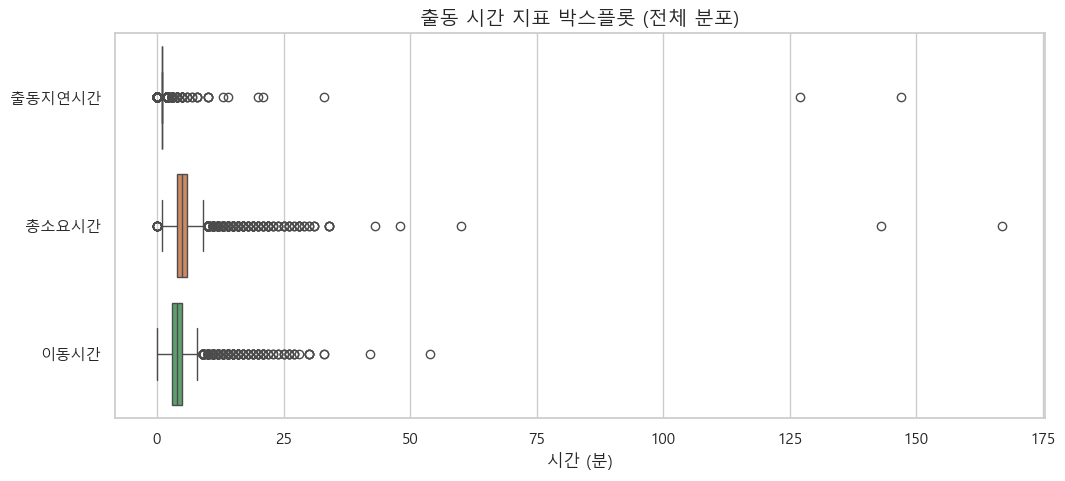

In [28]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

df = pd.read_csv("fire_master_analysis.csv", encoding="cp949")

sns.set(style = "whitegrid")

mpl.rcParams["font.family"] = "Malgun Gothic"
mpl.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(12,5))

data = df[["출동지연시간", "총소요시간", "이동시간"]]
sns.boxplot(data=data, orient="h")

plt.title("출동 시간 지표 박스플롯 (전체 분포)", fontsize=14)
plt.xlabel("시간 (분)")
plt.show()


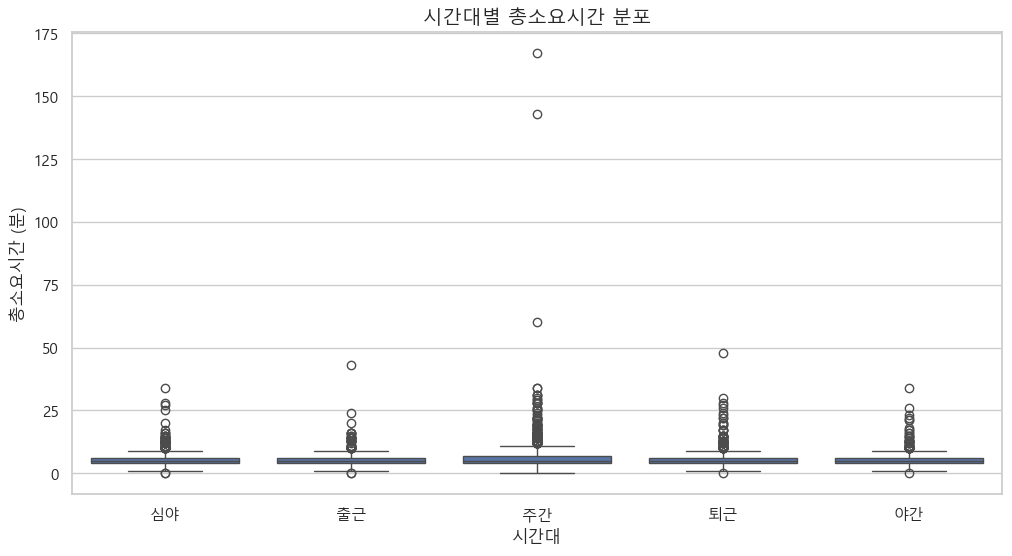

In [29]:
sns.set(style="whitegrid")
mpl.rcParams["font.family"] = "Malgun Gothic"
mpl.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="시간대",
    y="총소요시간",
    order=["심야", "출근", "주간", "퇴근", "야간"]
)

plt.title("시간대별 총소요시간 분포", fontsize=14)
plt.xlabel("시간대")
plt.ylabel("총소요시간 (분)")
plt.show()

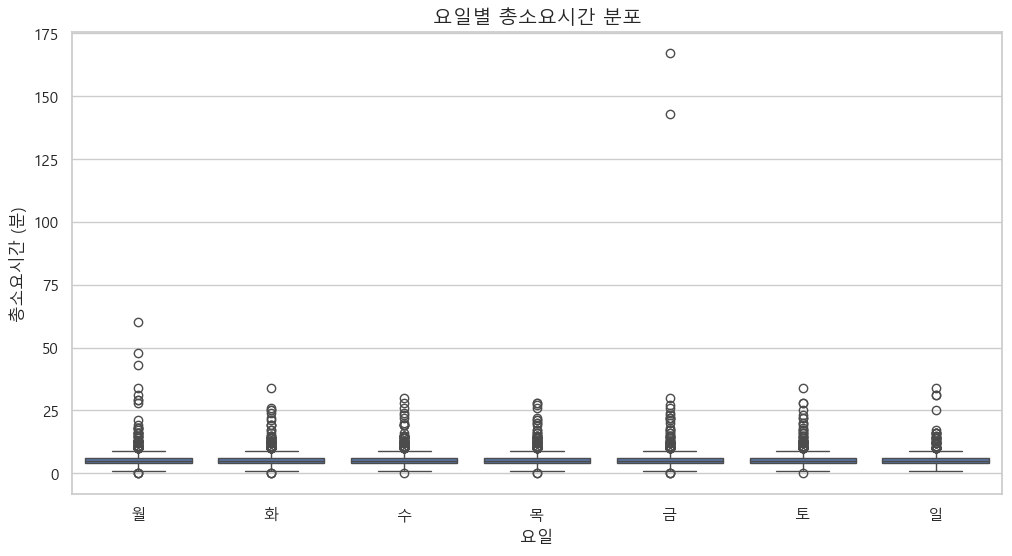

In [30]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="요일",
    y="총소요시간",
    order=["월", "화", "수", "목", "금", "토", "일"]
)

plt.title("요일별 총소요시간 분포", fontsize=14)
plt.xlabel("요일")
plt.ylabel("총소요시간 (분)")
plt.show()

In [32]:
summary = (
    df[["출동지연시간", "총소요시간", "이동시간"]]
    .describe(percentiles=[0.5, 0.75, 0.9, 0.95])
    .T
)

summary["IQR"] = summary["75%"] - summary["50%"]

summary

,count,mean,std,min,50%,75%,90%,95%,max,IQR
출동지연시간,5517.0,1.197752,2.763957,0.0,1.0,1.0,2.0,2.0,147.0,0.0
총소요시간,5516.0,5.787708,4.414934,0.0,5.0,6.0,9.0,12.0,167.0,1.0
이동시간,5517.0,4.589813,3.158857,0.0,4.0,5.0,7.0,10.0,54.0,1.0


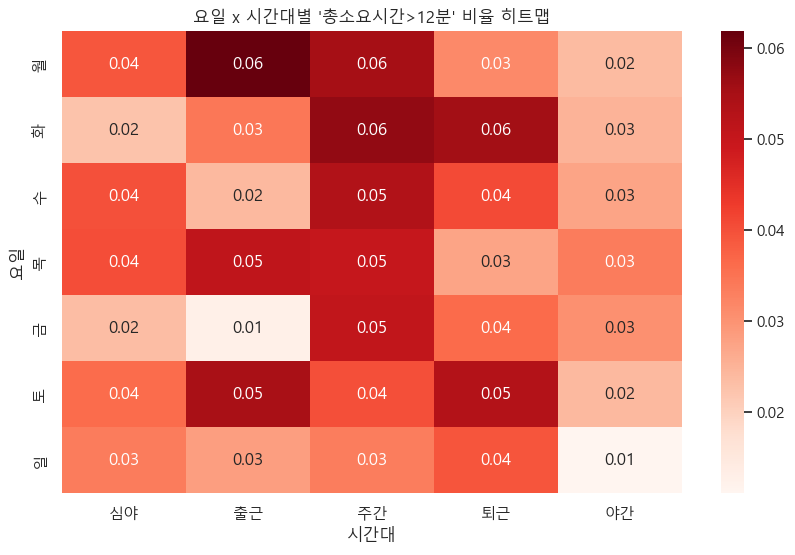

In [37]:
TH = 12
tmp = df.copy()
tmp["느림"] = (tmp["총소요시간"]>TH).astype(int)

pivot_slow = (
    tmp.groupby(["요일", "시간대"])["느림"]
    .mean()
    .reset_index()
    .pivot(index="요일", columns="시간대", values="느림")
    .reindex(index=["월", "화", "수", "목", "금", "토", "일"],
            columns=["심야", "출근", "주간", "퇴근", "야간"])
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot_slow, annot=True, fmt=".2f", cmap="Reds")

plt.title(f"요일 x 시간대별 '총소요시간>{TH}분' 비율 히트맵")
plt.xlabel("시간대")
plt.ylabel("요일")
plt.show()